# EV Mobility Pattern Analysis
**What do the daily mobility patterns of different user groups look like?**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Raw CSVs
trip_df      = pd.read_csv('../data/trip.csv', low_memory=False)
person_df    = pd.read_csv('../data/person.csv', low_memory=False)
household_df = pd.read_csv('../data/household.csv', low_memory=False)
vehicle_df   = pd.read_csv('../data/vehicle.csv', low_memory=False)

print('Trip rows:     ', len(trip_df))
print('Person rows:   ', len(person_df))
print('Household rows:', len(household_df))
print('Vehicle rows:  ', len(vehicle_df))

# ── Merge person + household ───────────────────────────────────────────────────
merged_df = pd.merge(person_df, household_df, on='HOUSEHOLD_ID', how='left')
print('\nMerged person+household:', len(merged_df))
print('Columns sample:', list(merged_df.columns[:10]))

Trip rows:      126874
Person rows:    39235
Household rows: 18015
Vehicle rows:   30868

Merged person+household: 39235
Columns sample: ['HOUSEHOLD_ID', 'PERSON_ID', 'AGE', 'AGE_GROUP', 'GENDER', 'RACEETHNICITY', 'MPO_RACEETHNICITY', 'RACEETHNICITY_HISPANIC', 'MPO_RACEETHNICITY_HISPANIC', 'LICENSE']


**Cell 2: Activity & Fuel Type Label Maps**

In [7]:
ACTIVITY_LABELS = {
    1: 'Home', 2: 'Work', 3: 'Volunteer', 4: 'School',
    5: 'Shopping', 6: 'Meal (quick-stop)', 7: 'Meal', 8: 'Gas',
    9: 'Health care', 10: 'Non-shopping errand', 11: 'Socialize',
    12: 'Civic/Religious', 13: 'Exercise', 14: 'Recreation',
    15: 'Entertainment', 16: 'Drop off/pick up', 18: 'Other', -9: None
}

FUELTYPE_LABELS = {
    1: 'Gas', 2: 'Diesel', 3: 'Plug-in Hybrid',
    4: 'Hybrid', 5: 'Electric', 6: 'Flex Fuel', 997: 'Other', -9: None
}

EV_FUEL_TYPES = {'Electric', 'Plug-in Hybrid'}

# Map activity codes to labels in trip_df
trip_df['O_ACTIVITY_LABEL'] = trip_df['O_ACTIVITY'].map(ACTIVITY_LABELS)
trip_df['D_ACTIVITY_LABEL'] = trip_df['D_ACTIVITY'].map(ACTIVITY_LABELS)

# Map fuel type in vehicle_df
vehicle_df['FUELTYPE_LABEL'] = vehicle_df['FUELTYPE'].map(FUELTYPE_LABELS)

# Flag EV vehicles
ev_vehicle_keys = set(
    zip(vehicle_df[vehicle_df['FUELTYPE_LABEL'].isin(EV_FUEL_TYPES)]['HOUSEHOLD_ID'],
        vehicle_df[vehicle_df['FUELTYPE_LABEL'].isin(EV_FUEL_TYPES)]['VEHNUM'])
)
print(f'EV/PHEV vehicles in dataset: {len(ev_vehicle_keys)}')

# Flag persons who drove an EV at least once
trip_df['is_ev_trip'] = [
    (row.HOUSEHOLD_ID, row.MODE_HH_VEHICLE) in ev_vehicle_keys
    for row in trip_df.itertuples(index=False)
]
ev_person_ids = set(trip_df[trip_df['is_ev_trip']]['PERSON_ID'])
print(f'Persons with at least one EV trip: {len(ev_person_ids)}')

EV/PHEV vehicles in dataset: 242
Persons with at least one EV trip: 258


## Cell 3: Assign Archetypes (Rule-Based)

Rules from AJ's archetype document:
- **Non-Commuter**: not a worker, or works from home
- **Parent Commuter**: worker + household has child under 18 with no license
- **Flexible Commuter**: worker + 2 or more non-work/home destination activities
- **Rigid Commuter**: worker + only 1 other activity besides work and home

In [8]:
# ── Identify households with children under 18 without a license ───────────────
# AGE column in person_df; LICENSE = 1 means has license
child_hh_ids = set(
    merged_df[(merged_df['AGE'] < 18) & (merged_df['LICENSE'] != 1)]['HOUSEHOLD_ID']
)
print(f'Households with unlicensed children: {len(child_hh_ids)}')

def classify_archetype(person_row, person_trips):
    
    # Non-commuter: not a worker (EMPLOYMENT_STATUS != 0) or works from home
    if person_row['EMPLOYMENT_STATUS'] != 0 or person_row.get('J1_WORKPLACE_LOC', -9) in (3, -9):
        return 'Non-Commuter'

    dest_activities = person_trips['D_ACTIVITY_LABEL'].dropna().tolist()
    has_work_trip = 'Work' in dest_activities

    if not has_work_trip:
        return 'Non-Commuter'

    # Parent Commuter: has work trip + household has child under 18 no license
    if person_row['HOUSEHOLD_ID'] in child_hh_ids:
        return 'Parent Commuter'

    # Count non-work, non-home destination activities
    other_activities = [a for a in dest_activities if a not in ('Home', 'Work')]
    if len(other_activities) >= 2:
        return 'Flexible Commuter'

    return 'Rigid Commuter'

# ── Apply to all licensed persons who have trips ───────────────────────────────
licensed = merged_df[merged_df['LICENSE'] == 1].copy()

archetype_records = []
for _, row in licensed.iterrows():
    person_trips = trip_df[trip_df['PERSON_ID'] == row['PERSON_ID']]
    if len(person_trips) == 0:
        continue
    archetype = classify_archetype(row, person_trips)
    archetype_records.append({
        'PERSON_ID':        row['PERSON_ID'],
        'HOUSEHOLD_ID':     row['HOUSEHOLD_ID'],
        'EMPLOYMENT_STATUS':row['EMPLOYMENT_STATUS'],
        'HHSIZE':           row['HHSIZE'],
        'HH_INCOME_BROAD':  row.get('HH_INCOME_BROAD', None),
        'HOME_TYPE':        row.get('HOME_TYPE', None),
        'AREA_TYPE':        row.get('AREA_TYPE', None),
        'has_ev':           row['PERSON_ID'] in ev_person_ids,
        'archetype':        archetype
    })

archetype_df = pd.DataFrame(archetype_records)

print('\nArchetype distribution (all licensed persons with trips):')
print(archetype_df['archetype'].value_counts())
print('\nArchetype distribution (EV users only):')
print(archetype_df[archetype_df['has_ev']]['archetype'].value_counts())

Households with unlicensed children: 3846

Archetype distribution (all licensed persons with trips):
archetype
Non-Commuter         11595
Rigid Commuter        7252
Parent Commuter       4110
Flexible Commuter     3396
Name: count, dtype: int64

Archetype distribution (EV users only):
archetype
Non-Commuter         79
Rigid Commuter       53
Parent Commuter      53
Flexible Commuter    26
Name: count, dtype: int64


## Cell 4: Parse Trip Times & Compute Dwell Time

**Dwell time** = time between arriving at a destination and departing for the next trip.
This is the window where charging could happen.

In [9]:
def hhmm_to_minutes(t):
    """Convert 'HH:MM' string to minutes since midnight. Returns NaN if invalid."""
    try:
        h, m = str(t).split(':')
        return int(h) * 60 + int(m)
    except:
        return np.nan

trip_df['dep_mins'] = trip_df['DEPARTURE_TIME_HHMM'].apply(hhmm_to_minutes)
trip_df['arr_mins'] = trip_df['ARRIVAL_TIME_HHMM'].apply(hhmm_to_minutes)

# Sort trips per person by departure time
trip_df_sorted = trip_df.sort_values(['PERSON_ID', 'dep_mins']).copy()

# Dwell time = next departure - current arrival (within same person)
trip_df_sorted['next_dep_mins'] = trip_df_sorted.groupby('PERSON_ID')['dep_mins'].shift(-1)
trip_df_sorted['dwell_mins'] = trip_df_sorted['next_dep_mins'] - trip_df_sorted['arr_mins']

# Remove negative or unrealistic dwell times (> 16 hours likely overnight, keep for home window)
trip_df_sorted['dwell_mins'] = trip_df_sorted['dwell_mins'].clip(lower=0, upper=960)

# Merge archetype into trip dataframe
trips_with_archetype = trip_df_sorted.merge(
    archetype_df[['PERSON_ID', 'archetype', 'has_ev']],
    on='PERSON_ID',
    how='inner'
)

print('Trips with archetype assigned:', len(trips_with_archetype))
print('\nSample dwell times (minutes):')
print(trips_with_archetype[['PERSON_ID', 'D_ACTIVITY_LABEL', 'arr_mins', 'next_dep_mins', 'dwell_mins']].head(10).to_string())

Trips with archetype assigned: 106388

Sample dwell times (minutes):
     PERSON_ID D_ACTIVITY_LABEL  arr_mins  next_dep_mins  dwell_mins
0  14000027101             Work       565          686.0       121.0
1  14000027101         Shopping       690          740.0        50.0
2  14000027101         Shopping       748          752.0         4.0
3  14000027101             Work       760         1014.0       254.0
4  14000027101             Home      1035            NaN         NaN
5  14000027103             Work       476         1020.0       544.0
6  14000027103             Home      1045            NaN         NaN
7  14000028001             Work       365          810.0       445.0
8  14000028001             Home       825         1065.0       240.0
9  14000028001         Shopping      1080         1100.0        20.0


## Cell 5: Classify Charging Opportunity Windows

Per the literature (NHTS EV charging study, NREL EVI-Pro):
- **≥ 60 minutes** = viable for Level 2 charging
- **≥ 30 minutes** = viable for slower L2 or opportunity charging
- Location categories: **Home**, **Work**, **Other destination**

In [10]:
def location_category(activity_label):
    if activity_label == 'Home':
        return 'Home'
    elif activity_label == 'Work':
        return 'Work'
    else:
        return 'Other'

trips_with_archetype['location_cat'] = trips_with_archetype['D_ACTIVITY_LABEL'].apply(location_category)

# Flag viable charging windows
trips_with_archetype['viable_l2_60']  = trips_with_archetype['dwell_mins'] >= 60
trips_with_archetype['viable_l2_30']  = trips_with_archetype['dwell_mins'] >= 30

# Per person: does this person have at least one viable window at each location type?
def person_charging_summary(group):
    return pd.Series({
        'has_home_window_60':  group[group['location_cat'] == 'Home']['viable_l2_60'].any(),
        'has_work_window_60':  group[group['location_cat'] == 'Work']['viable_l2_60'].any(),
        'has_other_window_60': group[group['location_cat'] == 'Other']['viable_l2_60'].any(),
        'has_home_window_30':  group[group['location_cat'] == 'Home']['viable_l2_30'].any(),
        'has_work_window_30':  group[group['location_cat'] == 'Work']['viable_l2_30'].any(),
        'has_other_window_30': group[group['location_cat'] == 'Other']['viable_l2_30'].any(),
        'max_dwell_mins':      group['dwell_mins'].max(),
        'num_trips':           len(group),
        'total_distance':      group['DISTANCE'].sum(),
        'archetype':           group['archetype'].iloc[0],
        'has_ev':              group['has_ev'].iloc[0],
    })

person_summary = trips_with_archetype.groupby('PERSON_ID').apply(person_charging_summary).reset_index()

print('Person-level charging summary shape:', person_summary.shape)
print(person_summary.head())

Person-level charging summary shape: (26353, 12)
     PERSON_ID  has_home_window_60  has_work_window_60  has_other_window_60  \
0  14000027101               False                True                False   
1  14000027103               False                True                False   
2  14000028001                True                True                 True   
3  14000028401               False               False                 True   
4  14000029101               False                True                False   

   has_home_window_30  has_work_window_30  has_other_window_30  \
0               False                True                 True   
1               False                True                False   
2                True                True                 True   
3               False               False                 True   
4               False                True                 True   

   max_dwell_mins  num_trips  total_distance          archetype  has_ev  
0    

## Cell 6: Per-Archetype Charging Window Summary Table

In [11]:
archetype_order = ['Parent Commuter', 'Non-Commuter', 'Flexible Commuter', 'Rigid Commuter']

summary_table = person_summary.groupby('archetype').agg(
    n_persons        = ('PERSON_ID', 'count'),
    pct_home_60      = ('has_home_window_60',  lambda x: round(x.mean() * 100, 1)),
    pct_work_60      = ('has_work_window_60',  lambda x: round(x.mean() * 100, 1)),
    pct_other_60     = ('has_other_window_60', lambda x: round(x.mean() * 100, 1)),
    pct_home_30      = ('has_home_window_30',  lambda x: round(x.mean() * 100, 1)),
    pct_work_30      = ('has_work_window_30',  lambda x: round(x.mean() * 100, 1)),
    pct_other_30     = ('has_other_window_30', lambda x: round(x.mean() * 100, 1)),
    mean_trips       = ('num_trips',           lambda x: round(x.mean(), 1)),
    mean_distance    = ('total_distance',      lambda x: round(x.mean(), 1)),
    mean_max_dwell   = ('max_dwell_mins',      lambda x: round(x.mean(), 1)),
).reindex(archetype_order)

print('=== CHARGING WINDOW SUMMARY BY ARCHETYPE ===')
print('(% of persons with at least one viable window at that location type)\n')
print(summary_table.to_string())

=== CHARGING WINDOW SUMMARY BY ARCHETYPE ===
(% of persons with at least one viable window at that location type)

                   n_persons  pct_home_60  pct_work_60  pct_other_60  pct_home_30  pct_work_30  pct_other_30  mean_trips  mean_distance  mean_max_dwell
archetype                                                                                                                                              
Parent Commuter         4110         16.2         97.1          23.2         22.3         97.6          37.3         4.2           41.6           439.3
Non-Commuter           11595         29.8          5.5          61.5         33.2          5.9          79.2         4.2           57.6           173.0
Flexible Commuter       3396         25.0         97.1          52.3         34.6         98.1          74.3         5.8           53.5           381.7
Rigid Commuter          7252          8.9         97.0          15.7         12.4         97.5          25.2         2.8     

## Cell 7: Visualization — Charging Windows by Archetype

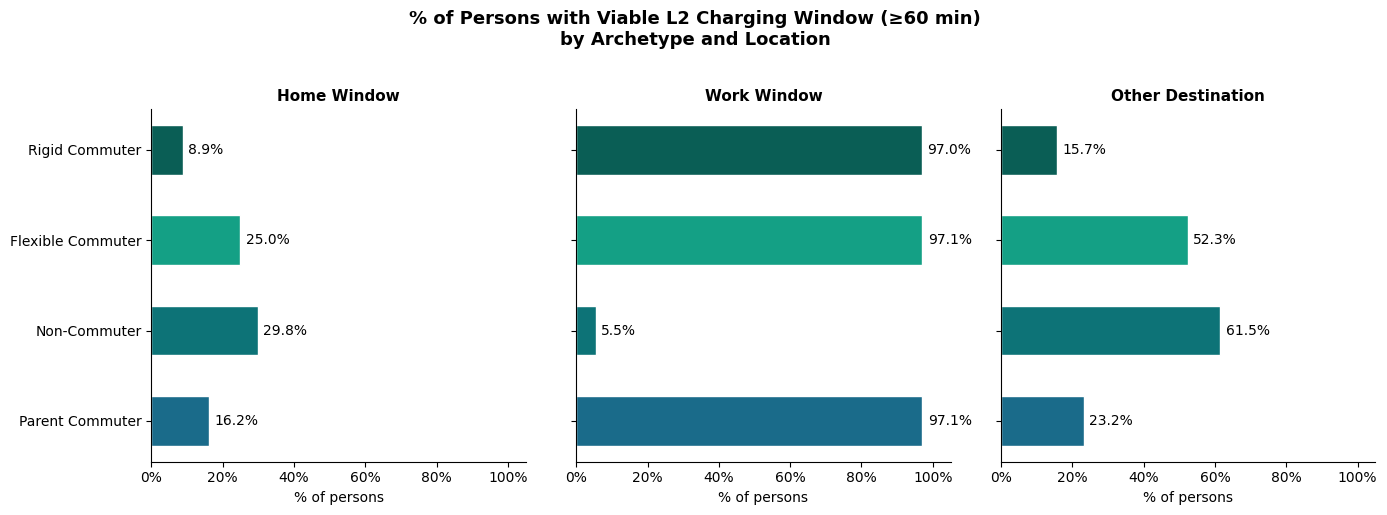

Saved to data/charging_windows_by_archetype.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle('% of Persons with Viable L2 Charging Window (≥60 min)\nby Archetype and Location', 
             fontsize=13, fontweight='bold', y=1.02)

colors = {'Parent Commuter': '#1A6B8A', 'Non-Commuter': '#0D7377',
          'Flexible Commuter': '#14A085', 'Rigid Commuter': '#0A5E55'}

locations = [
    ('pct_home_60',  'Home Window'),
    ('pct_work_60',  'Work Window'),
    ('pct_other_60', 'Other Destination'),
]

for ax, (col, title) in zip(axes, locations):
    data = summary_table[col].reindex(archetype_order)
    bar_colors = [colors[a] for a in data.index]
    bars = ax.barh(data.index, data.values, color=bar_colors, edgecolor='white', height=0.55)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('% of persons', fontsize=10)
    ax.set_xlim(0, 105)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, data.values):
        ax.text(val + 1.5, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/charging_windows_by_archetype.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/charging_windows_by_archetype.png')

## Cell 8: Visualization — Dwell Time Distributions by Archetype

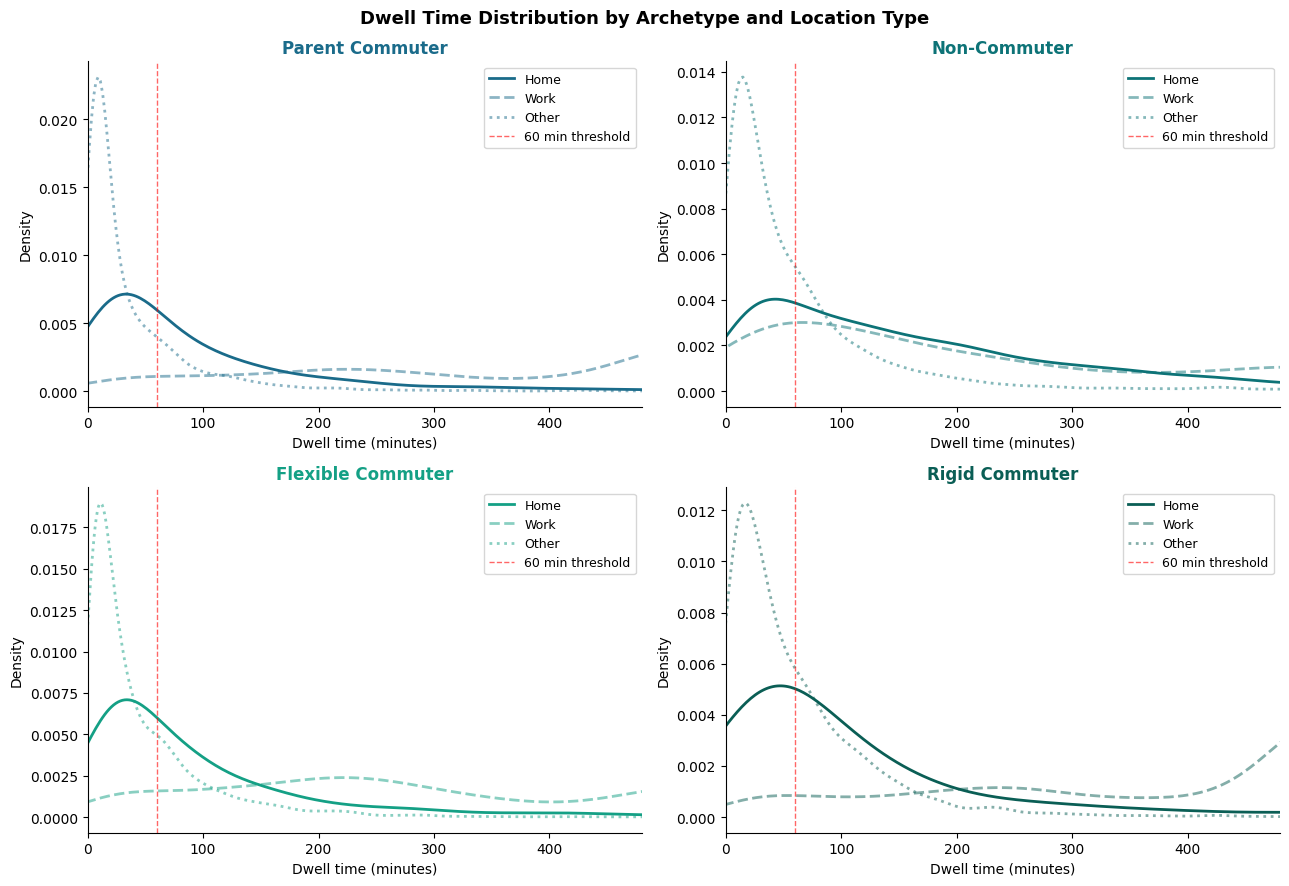

Saved to data/dwell_time_distributions.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Dwell Time Distribution by Archetype and Location Type',
             fontsize=13, fontweight='bold')

archetype_colors = {
    'Parent Commuter':   '#1A6B8A',
    'Non-Commuter':      '#0D7377',
    'Flexible Commuter': '#14A085',
    'Rigid Commuter':    '#0A5E55',
}

for ax, archetype in zip(axes.flatten(), archetype_order):
    subset = trips_with_archetype[
        (trips_with_archetype['archetype'] == archetype) &
        (trips_with_archetype['dwell_mins'].notna()) &
        (trips_with_archetype['dwell_mins'] > 0)
    ]
    for loc, ls in [('Home', '-'), ('Work', '--'), ('Other', ':')]:
        loc_data = subset[subset['location_cat'] == loc]['dwell_mins']
        if len(loc_data) > 10:
            loc_data.plot.kde(ax=ax, label=loc, linestyle=ls,
                              color=archetype_colors[archetype],
                              alpha=0.5 if loc != 'Home' else 1.0,
                              linewidth=2)
    ax.axvline(60, color='red', linestyle='--', linewidth=1, alpha=0.6, label='60 min threshold')
    ax.set_xlim(0, 480)
    ax.set_title(archetype, fontweight='bold', color=archetype_colors[archetype])
    ax.set_xlabel('Dwell time (minutes)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../data/dwell_time_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/dwell_time_distributions.png')

## Cell 9: Activity Sequence Analysis

What are the most common activity chains per archetype?

In [14]:
# Build activity chain per person: sequence of destination activities
chains = (
    trips_with_archetype
    .sort_values(['PERSON_ID', 'dep_mins'])
    .groupby('PERSON_ID')
    .agg(
        chain    = ('D_ACTIVITY_LABEL', lambda x: ' → '.join(x.dropna().astype(str))),
        archetype= ('archetype', 'first')
    )
    .reset_index()
)

print('=== TOP 5 ACTIVITY CHAINS PER ARCHETYPE ===\n')
for archetype in archetype_order:
    top = (
        chains[chains['archetype'] == archetype]['chain']
        .value_counts()
        .head(5)
    )
    print(f'--- {archetype} ---')
    for chain, count in top.items():
        print(f'  {count:4d}  {chain}')
    print()

=== TOP 5 ACTIVITY CHAINS PER ARCHETYPE ===

--- Parent Commuter ---
  1100  Work → Home
   160  Drop off/pick up → Work → Home
   151  Drop off/pick up → Work → Drop off/pick up → Home
   112  Work → Drop off/pick up → Home
    96  Work → Shopping → Home

--- Non-Commuter ---
   749  Shopping → Home
   281  School → Home
   270  Meal → Home
   265  Health care → Home
   200  Shopping → Shopping → Home

--- Flexible Commuter ---
    50  Work → Shopping → Shopping → Home
    50  Drop off/pick up → Work → Drop off/pick up → Home
    45  Work → Meal → Work → Shopping → Home
    22  Work → Meal (quick-stop) → Work → Shopping → Home
    21  Work → Non-shopping errand → Shopping → Home

--- Rigid Commuter ---
  3523  Work → Home
   517  Work → Shopping → Home
   230  Work → Meal → Work → Home
   155  Work → Home → Meal → Home
   153  Work → Meal → Home



## Cell 10: Statistical Test — Kruskal-Wallis

Test whether dwell times and trip counts differ significantly across archetypes.
Using Kruskal-Wallis (non-parametric) since distributions are not normal.

In [15]:
from scipy.stats import kruskal

metrics = [
    ('num_trips',      'Number of trips per day'),
    ('total_distance', 'Total daily distance (miles)'),
    ('max_dwell_mins', 'Max dwell time (minutes)'),
]

print('=== KRUSKAL-WALLIS TESTS ACROSS ARCHETYPES ===\n')
print(f'{"Metric":<35} {"H-statistic":>12} {"p-value":>12} {"Significant":>12}')
print('-' * 75)

for col, label in metrics:
    groups = [
        person_summary[person_summary['archetype'] == a][col].dropna().values
        for a in archetype_order
    ]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        h_stat, p_val = kruskal(*groups)
        sig = 'YES ***' if p_val < 0.001 else ('YES *' if p_val < 0.05 else 'no')
        print(f'{label:<35} {h_stat:>12.2f} {p_val:>12.4f} {sig:>12}')

print('\nSignificant p < 0.05 means archetype groups differ meaningfully on that metric.')


=== KRUSKAL-WALLIS TESTS ACROSS ARCHETYPES ===

Metric                               H-statistic      p-value  Significant
---------------------------------------------------------------------------
Number of trips per day                  5749.98       0.0000      YES ***
Total daily distance (miles)             1335.31       0.0000      YES ***
Max dwell time (minutes)                12222.53       0.0000      YES ***

Significant p < 0.05 means archetype groups differ meaningfully on that metric.


## Cell 11: EV Users vs All Users — Quick Comparison

In [16]:
ev_summary = person_summary.groupby(['archetype', 'has_ev']).agg(
    n             = ('PERSON_ID', 'count'),
    mean_trips    = ('num_trips',      lambda x: round(x.mean(), 1)),
    mean_distance = ('total_distance', lambda x: round(x.mean(), 1)),
    pct_home_60   = ('has_home_window_60', lambda x: round(x.mean() * 100, 1)),
    pct_work_60   = ('has_work_window_60', lambda x: round(x.mean() * 100, 1)),
).reset_index()

ev_summary['user_type'] = ev_summary['has_ev'].map({True: 'EV User', False: 'Non-EV User'})

print('=== EV USERS vs NON-EV USERS BY ARCHETYPE ===\n')
print(ev_summary[['archetype', 'user_type', 'n', 'mean_trips',
                   'mean_distance', 'pct_home_60', 'pct_work_60']]
      .sort_values(['archetype', 'user_type'])
      .to_string(index=False))

=== EV USERS vs NON-EV USERS BY ARCHETYPE ===

        archetype   user_type     n  mean_trips  mean_distance  pct_home_60  pct_work_60
Flexible Commuter     EV User    26         5.6           48.4         19.2         96.2
Flexible Commuter Non-EV User  3370         5.9           53.6         25.1         97.2
     Non-Commuter     EV User    79         4.8          114.1         44.3          5.1
     Non-Commuter Non-EV User 11516         4.2           57.2         29.7          5.5
  Parent Commuter     EV User    53         4.3           48.2         17.0        100.0
  Parent Commuter Non-EV User  4057         4.2           41.5         16.2         97.0
   Rigid Commuter     EV User    53         3.0           30.0         24.5         94.3
   Rigid Commuter Non-EV User  7199         2.8           31.8          8.8         97.0


## Cell 12: Final Summary — What This Tells Us for RQ3

This cell prints a plain-language interpretation for each archetype.

In [17]:
interpretations = {
    'Parent Commuter': (
        "School run breaks up the day into short windows. "
        "Home charging is primary. Workplace charging viable if available, "
        "but mid-day windows are short and fragmented."
    ),
    'Non-Commuter': (
        "Low overall mobility means long home dwell times. "
        "Home charging dominant. No workplace window. "
        "Mid-day destination stops tend to be short and unpredictable."
    ),
    'Flexible Commuter': (
        "Multiple mid-day stops create several potential charging windows. "
        "Best archetype for destination and workplace L2 charging. "
        "Also has long home window overnight."
    ),
    'Rigid Commuter': (
        "Tight work-home schedule with very few detours. "
        "Long workplace dwell window is the main public charging opportunity. "
        "Home charging covers overnight. DC fast charging needed for any unexpected gaps."
    ),
}

print('=== RQ3 IMPLICATIONS: CHARGING NEEDS BY ARCHETYPE ===\n')
for archetype in archetype_order:
    row = summary_table.loc[archetype]
    print(f'▶ {archetype}')
    print(f'  N={int(row["n_persons"])} | Avg trips/day: {row["mean_trips"]} | Avg distance: {row["mean_distance"]} mi')
    print(f'  Home ≥60min: {row["pct_home_60"]}% | Work ≥60min: {row["pct_work_60"]}% | Other ≥60min: {row["pct_other_60"]}%')
    print(f'  → {interpretations[archetype]}')
    print()

=== RQ3 IMPLICATIONS: CHARGING NEEDS BY ARCHETYPE ===

▶ Parent Commuter
  N=4110 | Avg trips/day: 4.2 | Avg distance: 41.6 mi
  Home ≥60min: 16.2% | Work ≥60min: 97.1% | Other ≥60min: 23.2%
  → School run breaks up the day into short windows. Home charging is primary. Workplace charging viable if available, but mid-day windows are short and fragmented.

▶ Non-Commuter
  N=11595 | Avg trips/day: 4.2 | Avg distance: 57.6 mi
  Home ≥60min: 29.8% | Work ≥60min: 5.5% | Other ≥60min: 61.5%
  → Low overall mobility means long home dwell times. Home charging dominant. No workplace window. Mid-day destination stops tend to be short and unpredictable.

▶ Flexible Commuter
  N=3396 | Avg trips/day: 5.8 | Avg distance: 53.5 mi
  Home ≥60min: 25.0% | Work ≥60min: 97.1% | Other ≥60min: 52.3%
  → Multiple mid-day stops create several potential charging windows. Best archetype for destination and workplace L2 charging. Also has long home window overnight.

▶ Rigid Commuter
  N=7252 | Avg trips/day: 2